Total detected objects: 32
Detected circles: 8
Estimated ellipse-like objects: 24


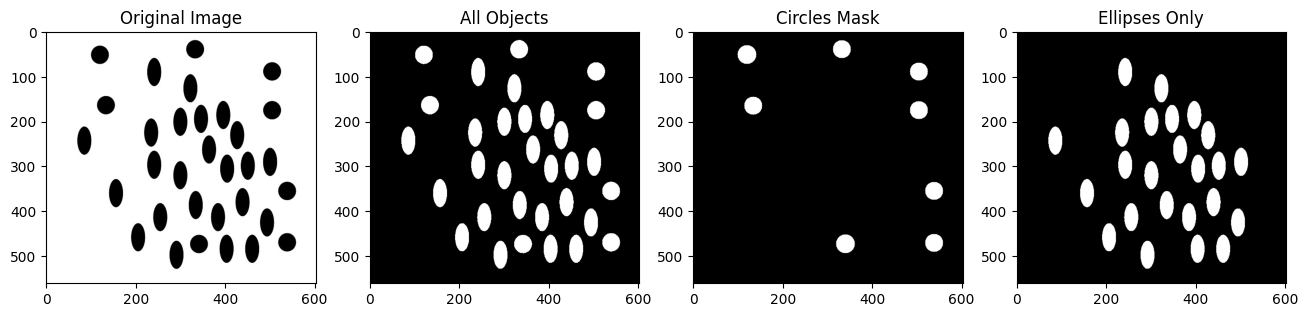

In [ ]:
# Import libraries
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Read the original image
img_original = cv.imread('images/blobs.jpg')

# Create a copy of original image
img = img_original.copy()

# Convert image to grayscale
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Detect circles using Hough Circle Transform
circles = cv.HoughCircles(
    gray,
    cv.HOUGH_GRADIENT,
    dp=1,
    minDist=10,
    param1=100,
    param2=35,
    minRadius=10,
    maxRadius=30
)

# Create a binary mask for detected circles
circles_mask = np.zeros(gray.shape, dtype=np.uint8)

if circles is not None:
    circles = np.uint16(np.around(circles))
    for c in circles[0, :]:
        center_x, center_y, radius = c
        center = (center_x, center_y)

        # Draw each detected circle as a filled white region on the mask
        cv.circle(circles_mask, center, radius, 255, -1)

# Create a binary mask for all dark objects in the image
_, objects_mask = cv.threshold(gray, 127, 255, cv.THRESH_BINARY_INV)

# Remove circle regions from the object mask to keep only ellipse-like objects
ellipses = cv.bitwise_and(objects_mask, cv.bitwise_not(circles_mask))

# Apply morphological opening to remove small noise and thin artifacts
kernel = np.ones((3, 3), np.uint8)
ellipses_clean = cv.morphologyEx(ellipses, cv.MORPH_OPEN, kernel)

# Threshold again to prepare the image for contour extraction
_, thresh = cv.threshold(gray, 127, 255, cv.THRESH_BINARY_INV)

# Find external contours of all detected blobs in the image
contours, _ = cv.findContours(thresh, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)

# Display images
plt.figure(figsize=(16, 4))
plt.subplot(1, 4, 1); plt.imshow(img_original[..., ::-1]); plt.title('Original Image')
plt.subplot(1, 4, 2); plt.imshow(objects_mask, cmap='gray'); plt.title('All Objects')
plt.subplot(1, 4, 3); plt.imshow(circles_mask, cmap='gray'); plt.title('Circles Mask')
plt.subplot(1, 4, 4); plt.imshow(ellipses_clean, cmap='gray'); plt.title('Ellipses Only');

# Count detected circles
num_circles = 0 if circles is None else len(circles[0])

# Count all detected blobs
num_objects = len(contours)

# Estimate the number of ellipses by subtracting circles from all objects
num_ellipses = num_objects - num_circles

print(f"Total detected objects: {num_objects}")
print(f"Detected circles: {num_circles}")
print(f"Estimated ellipse-like objects: {num_ellipses}")